## Section 1. Config

In [1]:
# Configuration
TARGET = "Kepler-5b"  # Change this to your target
MISSION = "Kepler"  # or "TESS"
SIGMA_CLIP = 5.0
DOWNLOAD_ALL = True  # Set to True to download all available files and stitch them

USE_TLS = False
VERBOSE = True
REFINE_DURATION = True
SYSTEMATICS_CORRECTION = "off" # off, cbv, reg, both
INCLUDE_ML_CUTOUTS = False
ACCEPTANCE_FACTOR_FOR_SHORT_MOVES = 0.85

# Eclipse
MASK_ECLIPSES = False
ECLIPSE_NSIGMA = 10.0
ECLIPSE_MIN_DEPTH_ABS = 0.02
ECLIPSE_MIN_GROUP = 6
ECLIPSE_PAD_POINTS = 2
ECLIPSE_MAX_MASK_FRACTION = 0.8


## Section 2. Imports

In [2]:
import numpy as np
import lightkurve as lk
import matplotlib.pyplot as plt
import os
import datetime
import pandas as pd

/home/henrique/Documents/GitHub/Gatonautas/.venv/lib/python3.14/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## Section 3. Processing

(Moved to standalone files)

## Section 4. Downloading data

In [3]:
print(f"Searching for {TARGET} in {MISSION} mission...")
search_result = lk.search_lightcurve(TARGET, mission=MISSION)
print(f"Found {len(search_result)} light curve files")


Searching for Kepler-5b in Kepler mission...
Found 52 light curve files


In [ ]:
from download_and_clean import download_and_clean_lightcurve
lc = download_and_clean_lightcurve(TARGET, MISSION, SIGMA_CLIP, all=DOWNLOAD_ALL, verbose=VERBOSE)

Downloaded 52 light curves
Stitched all light curves together
Original data points: 1505559


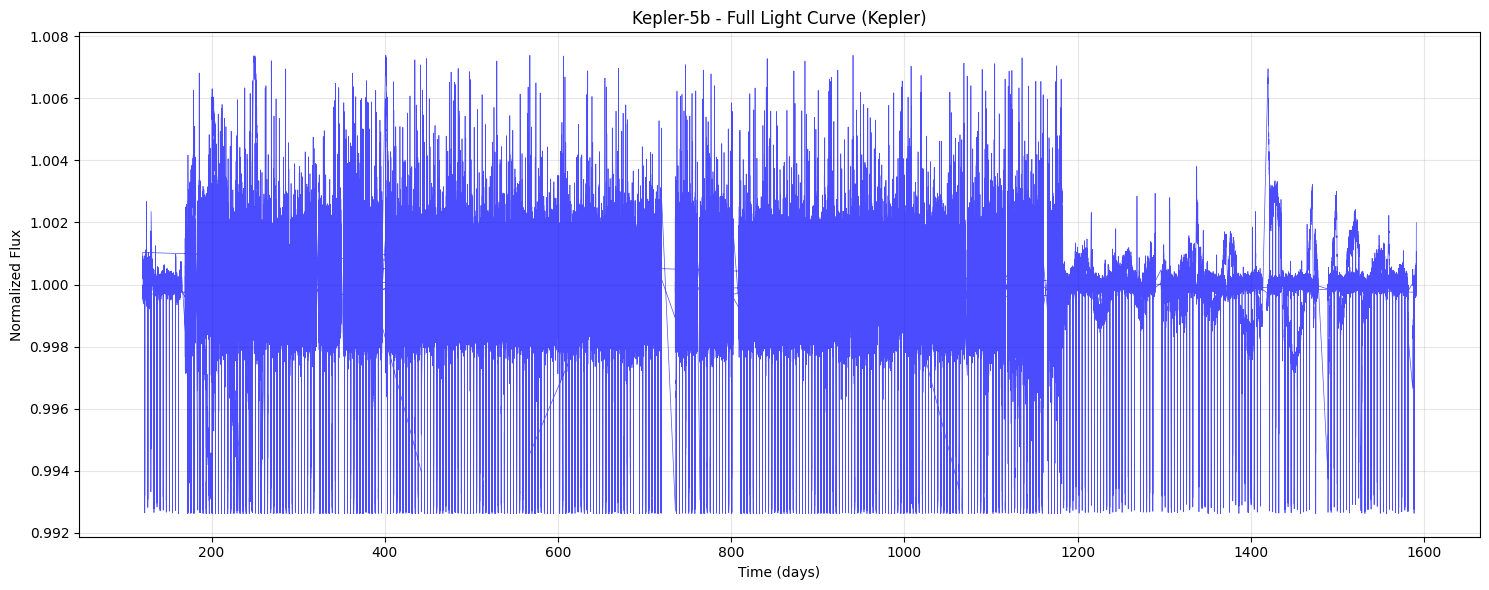

In [ ]:
# Plot the full light curve
plt.figure(figsize=(15, 6))
plt.plot(lc.time.value, lc.flux.value, 'b-', alpha=0.7, linewidth=0.5)
plt.xlabel('Time (days)')
plt.ylabel('Normalized Flux')
plt.title(f'{TARGET} - Full Light Curve ({MISSION})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


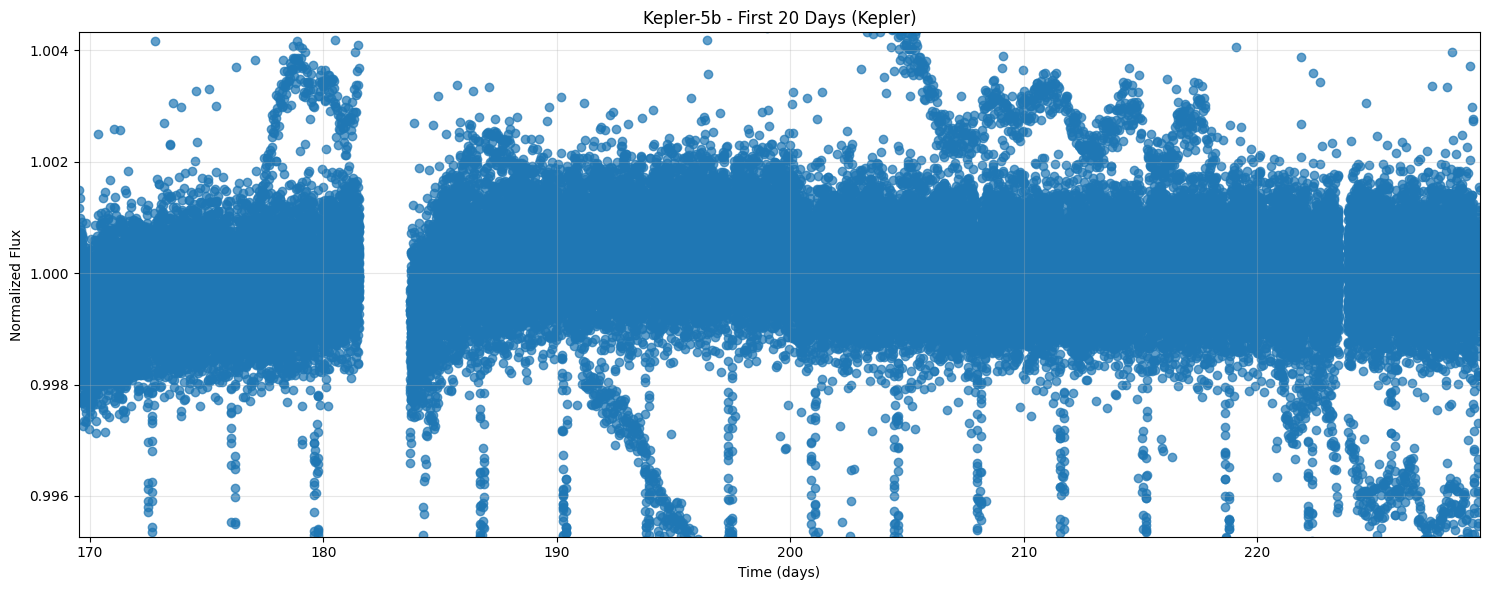

In [ ]:
# Plot the full light curve
# Plot the first 20 days of the light curve
plt.figure(figsize=(15, 6))
mask = (lc.time.value <= lc.time.value[0] + 60)
plt.scatter(lc.time.value[mask], lc.flux.value[mask], alpha=0.7, linewidth=1.0)
plt.xlabel('Time (days)')
plt.ylabel('Normalized Flux')
plt.title(f'{TARGET} - First 20 Days ({MISSION})')
plt.xlim(lc.time.value[0], lc.time.value[0] + 60)
# Set y-axis limits to zoom in around the data
y_data = lc.flux.value[mask]
y_mean = np.mean(y_data)
y_std = np.std(y_data)
plt.ylim(y_mean - 3*y_std, y_mean + 3*y_std)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Section 5. Feature extraction

In [8]:
from extract_feats import extract_all_features_from_lightcurve

# Extract features using the pipeline
print("Extracting features...")
feats = extract_all_features_from_lightcurve(lc, refine_duration=REFINE_DURATION, verbose=VERBOSE, use_tls=USE_TLS)
print("\nFeature extraction completed!")


Extracting features...
Starting feature extraction from arrays...
Data loaded: 1,505,069 valid points
Time range: 120.54 to 1591.00 days
Flux range: 0.978382 to 1.212733
Starting BLS detrending and period search...
Pre-BLS stitching: 144 segments, winsor 0.3% per segment
BLS input: 1,505,069 valid points
Masked eclipses: 4,241 points | depth med=0.00756
Period search range: 0.500 to 200.000 days
Duration search range: 0.0100 to 0.4500 days
Search grid: 2000 periods × 200 durations = 400,000 combinations
Computing BLS periodogram...
BLS periodogram computed successfully
dt_days = 0.0006811181592638604
dur grid: 0.01 0.45 200
best before refine: 0.45
Initial BLS result: P=3.5503 days, T14=0.4500 days, t0=122.61
Starting period/duration refinement...
Running period de-aliasing...
Transit mask created: 83,738 transit points, 1,421,331 out-of-transit points
Starting iterative spline detrending...
Spline iteration 1: 1,416,693 points used for fitting
Spline iteration 2: 1,416,625 points used

In [9]:
# Display extracted features
print("\n=== EXTRACTED FEATURES ===")
for key, value in feats.items():
    if isinstance(value, float):
        print(f"{key}: {value:.6f}")
    else:
        print(f"{key}: {value}")



=== EXTRACTED FEATURES ===
period_days: 3.548344
t0: 122.920410
duration_days: 0.195995
duration_hours: 4.703869
scale_mean: -0.161161
scale_std: 1.000000
scale_skewness: 1.551166
scale_kurtosis: 415.528296
scale_outlier_resistance: 0.140592
local_noise: 0.000660
depth_stability: 0.200029
acf_lag_1h: 0.555953
acf_lag_3h: 0.145282
acf_lag_6h: -0.033591
acf_lag_12h: -0.035783
acf_lag_24h: -0.029362
cadence_hours: 0.016347
depth_mean_per_transit: 0.008478
depth_std_per_transit: 0.001509
npts_transit_median: 1214.500000
cdpp_3h: 979.968325
cdpp_6h: 1135.495281
cdpp_12h: 1435.589305
SES_mean: 7.935948
SES_std: 1.412207
MES: 159.184504
snr_global: 7.935948
snr_per_transit_mean: 7.935948
snr_per_transit_std: 1.412207
resid_rms_global: 0.001666
vshape_metric: 0.833739
secondary_depth: 0.001076
secondary_depth_snr: 804.293603
secondary_depth_snr_log: 0.696706
secondary_depth_snr_capped: 1.007130
odd_even_depth_ratio: 1.000027
ingress_egress_asymmetry: 0.002445
skewness_flux: 1.551166
kurtosis_

## Section 6. Feature saving

In [10]:
current_date = datetime.datetime.now().strftime("%Y%m%d")

output_dir = "./data/feature_results"
os.makedirs(output_dir, exist_ok=True)

filename = f"{TARGET}_{current_date}.csv"
output_path = os.path.join(output_dir, filename)

df = pd.DataFrame([feats])
df.to_csv(output_path, index=False)

print(f"Features saved to: {output_path}")
print(f"Total features: {len(feats)}")
print(f"File size: {os.path.getsize(output_path) / 1024:.2f} KB")

Features saved to: ./data/feature_results/Kepler-5b_20260423.csv
Total features: 42
File size: 1.40 KB


## Section 7. Data plotting


Detected period: 3.5483 days
Transit epoch: 122.9204 days


ValueError: not enough values to unpack (expected 3, got 2)

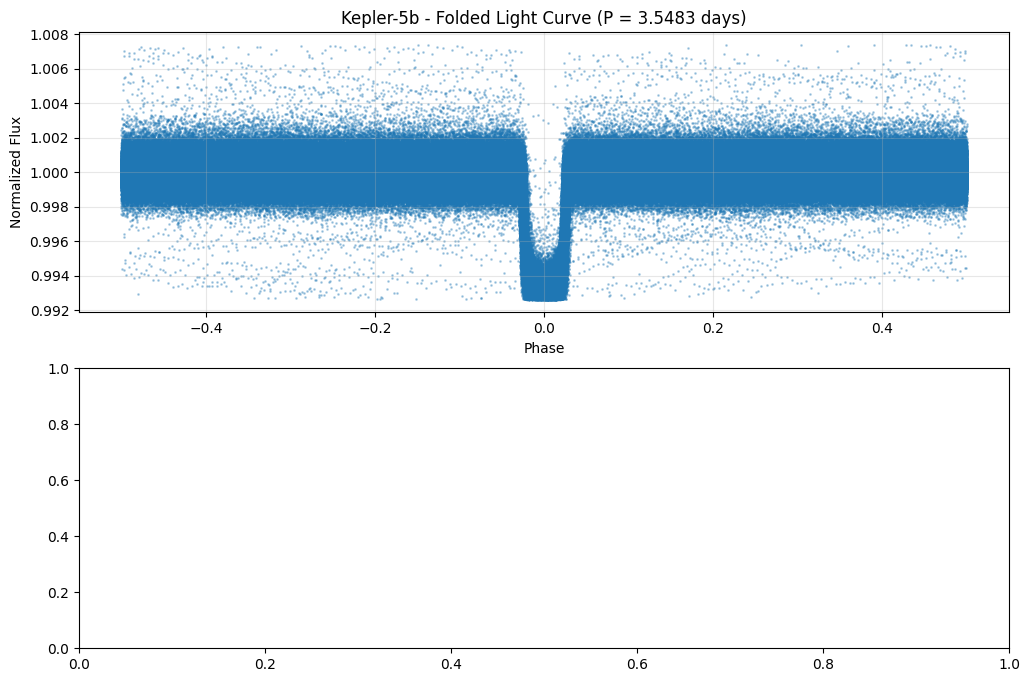

In [ ]:
# Plot folded light curve if period was detected
period = feats.get('period_days', np.nan)
t0 = feats.get('t0', np.nan)

if np.isfinite(period) and np.isfinite(t0):
    print(f"\nDetected period: {period:.4f} days")
    print(f"Transit epoch: {t0:.4f} days")
    
    # Fold the light curve
    phase = ((lc.time.value - t0) / period) % 1.0
    phase = (phase + 0.5) % 1.0 - 0.5
    
    plt.figure(figsize=(12, 8))
    
    # Plot folded light curve
    plt.subplot(2, 1, 1)
    plt.scatter(phase, lc.flux.value, alpha=0.3, s=1)
    plt.xlabel('Phase')
    plt.ylabel('Normalized Flux')
    plt.title(f'{TARGET} - Folded Light Curve (P = {period:.4f} days)')
    plt.grid(True, alpha=0.3)
    
    # Binned folded light curve
    plt.subplot(2, 1, 2)
    bins = np.linspace(-0.5, 0.5, 101)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    binned_flux, _, _ = np.histogram(phase, bins=bins, weights=lc.flux.value)
    binned_counts, _, _ = np.histogram(phase, bins=bins)
    binned_flux = binned_flux / np.maximum(binned_counts, 1)
    
    plt.plot(bin_centers, binned_flux, 'ro-', markersize=4, linewidth=2)
    plt.xlabel('Phase')
    plt.ylabel('Binned Flux')
    plt.title('Binned Folded Light Curve')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate and display transit depth
    depth = feats.get('depth_mean_per_transit', np.nan)
    if np.isfinite(depth):
        print(f"Transit depth: {depth:.6f} ({depth*100:.4f}%)")
else:
    print("\nNo valid period detected - cannot fold light curve")


In [ ]:
# Summary statistics
print("\n=== SUMMARY ===")
print(f"Target: {TARGET}")
print(f"Mission: {MISSION}")
print(f"Data points: {len(lc.time):,}")
print(f"Time span: {lc.time[-1].value - lc.time[0].value:.2f} days")
print(f"Cadence: {feats.get('cadence_hours', np.nan):.2f} hours")
print(f"Period: {feats.get('period_days', np.nan):.4f} days")
print(f"Duration: {feats.get('duration_hours', np.nan):.2f} hours")
print(f"MES: {feats.get('MES', np.nan):.2f}")
print(f"SNR (global): {feats.get('snr_global', np.nan):.2f}")